# 이벤트 스터디 (Event Study) — CAR 분석
## 지정학적 위기 시 비트코인은 디지털 금인가?
### 캡스톤디자인 | 팀명: 분석많이된다

---

## 데이터 현황 (master_data.csv 기준)

| 이벤트 | 거래일 | 기준일 전 | 기준일 후 |
|---|---|---|---|
| hormuz | 34일 | 17일 | 17일 |
| soleimani | 34일 | 17일 | 17일 |
| russia_ukraine_war | 35일 | 17일 | 18일 |
| israel_hamas_war | 38일 | 20일 | 18일 |
| israel_iran_war | 37일 | 17일 | 20일 |
| us_israel_iran_war | 38일 | 19일 | 19일 |

## 이벤트 창 설정 — 수정 사항

> **기존 코드: `±25`거래일** → 데이터가 최대 20일밖에 없어서 대부분 이벤트에서 창이 잘림
>
> **수정: `±17`거래일** → 모든 이벤트에서 확보 가능한 최소 공통 거래일 수

## 판단 기준 — Baur & Lucey (2010)

| 조건 | 분류 |
|---|---|
| CAR > 0 & p < 0.05 | **Safe Haven** ✅ |
| CAR > 0 & p ≥ 0.05 | **Diversifier** |
| CAR < 0 & p < 0.05 | **Risky Asset** ❌ |
| CAR < 0 & p ≥ 0.05 | **비유의** |

## 방법론

```
추정 기간: 이벤트 전 [-120, -26] 거래일  → returns.csv 전체에서 슬라이싱
이벤트 창: [-17, +17] 거래일              → master_data에서 슬라이싱

BTC               → CMRM (추정 기간 평균 수익률)
Gold, TLT, DXY,
NASDAQ            → Market Model (OLS, 독립변수: SP500)

AR(t) = 실제 수익률(t) − 정상 수익률(t)
CAR   = Σ AR(t)
검정  = t-test + Bootstrap (5,000회)
```

## 필요 파일

```
master_data.csv   ← 이벤트 기간 수익률 + GPR_custom + VIX + Fear&Greed
returns.csv       ← 추정 기간용 (전체 수익률, 2019-05-01~)
```

---
## Step 0. 라이브러리

In [2]:
# !pip install pandas numpy matplotlib scipy statsmodels --quiet

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import warnings, os, platform
warnings.filterwarnings('ignore')

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 130

EVENT_DATES = {
    'hormuz'          : '2019-06-13',
    'soleimani': '2020-01-03',
    'russia_ukraine_war': '2022-02-24',
    'israel_hamas_war'           : '2023-10-07',
    'israel_iran_war'            : '2024-04-01',
    'us_israel_iran_war'         : '2026-02-28',
}
EVENT_LABELS = {
    'hormuz'          : '호르무즈 위기',
    'soleimani': '솔레이마니 암살',
    'russia_ukraine_war': '러-우 전쟁',
    'israel_hamas_war'           : '이스라엘-하마스',
    'israel_iran_war'            : '이스라엘-이란 충돌',
    'us_israel_iran_war'         : '이란 전쟁',
}
ASSETS      = ['BTC', 'Gold', 'TLT', 'DXY', 'NASDAQ']
CMRM_ASSETS = ['BTC']
MM_ASSETS   = ['Gold', 'TLT', 'DXY', 'NASDAQ']
MARKET      = 'SP500'

# ── 수정된 이벤트 창 ──────────────────────────────────
# 기존 ±25 → ±17 로 수정
# 이유: master_data.csv가 이벤트별 약 34~38 거래일
#       기준일 전후 최소 17일만 보장됨
EVENT_WINDOW = 17

EST_START = -120   # 추정 기간 시작 (이벤트 전 120거래일)
EST_END   = -26    # 추정 기간 끝   (이벤트 전 26거래일)
N_BOOT    = 5000

ASSET_COLORS = {
    'BTC'   : '#F7931A',
    'Gold'  : '#DAA520',
    'TLT'   : '#2196F3',
    'DXY'   : '#9C27B0',
    'NASDAQ': '#E91E63',
}

print('✅ 환경 설정 완료')
print(f'   이벤트 창: ±{EVENT_WINDOW} 거래일')
print(f'   추정 기간: [{EST_START}, {EST_END}] 거래일')
print(f'   Bootstrap: {N_BOOT:,}회')

✅ 환경 설정 완료
   이벤트 창: ±17 거래일
   추정 기간: [-120, -26] 거래일
   Bootstrap: 5,000회


---
## Step 1. 데이터 로드

In [4]:
# ── master_data.csv ──────────────────────────────────
if not os.path.exists('master_data.csv'):
    raise FileNotFoundError('master_data.csv 없음')

master = pd.read_csv('master_data.csv')
master['date']       = pd.to_datetime(master['date'])
master['event_date'] = pd.to_datetime(master['event_date'])
for col in ASSETS + [MARKET, 'GPR_custom', 'VIX', 'fear_greed_lag1']:
    if col in master.columns:
        master[col] = pd.to_numeric(master[col], errors='coerce')

# ── returns.csv (추정 기간용 전체 수익률) ─────────────
if not os.path.exists('returns.csv'):
    raise FileNotFoundError('returns.csv 없음')

ret_all = pd.read_csv('returns.csv')
ret_all.columns = [c.strip() for c in ret_all.columns]
if 'Date' in ret_all.columns:
    ret_all = ret_all.rename(columns={'Date': 'date'})
ret_all['date'] = pd.to_datetime(ret_all['date'])
ret_all = ret_all.sort_values('date').reset_index(drop=True)
for col in ASSETS + [MARKET]:
    if col in ret_all.columns:
        ret_all[col] = pd.to_numeric(ret_all[col], errors='coerce')

print(f'✅ master_data : {len(master)}행  '
      f'({master["date"].min().date()} ~ {master["date"].max().date()})')
print(f'✅ returns_all : {len(ret_all)}행  '
      f'({ret_all["date"].min().date()} ~ {ret_all["date"].max().date()})')
print(f'\n이벤트별 거래일 / 기준일 전·후:')
print(f'{"이벤트":<30} {"전체":>5} {"기준일전":>8} {"기준일후":>8} {"창 충족":>8}')
print('-' * 65)
for ev, ed in EVENT_DATES.items():
    sub    = master[master['event_name']==ev].sort_values('date')
    ed_ts  = pd.Timestamp(ed)
    before = len(sub[sub['date'] < ed_ts])
    after  = len(sub[sub['date'] >= ed_ts])
    ok     = '✅' if before >= EVENT_WINDOW and after >= EVENT_WINDOW else '⚠️ 부족'
    print(f'{ev:<30} {len(sub):>5} {before:>8} {after:>8} {ok:>8}')

✅ master_data : 216행  (2019-05-20 ~ 2026-03-26)
✅ returns_all : 1735행  (2019-05-02 ~ 2026-03-26)

이벤트별 거래일 / 기준일 전·후:
이벤트                               전체     기준일전     기준일후     창 충족
-----------------------------------------------------------------
hormuz                     34       17       17        ✅
soleimani           34       17       17        ✅
russia_ukraine_war           35       17       18        ✅
israel_hamas_war                      38       20       18        ✅
israel_iran_war                       37       17       20        ✅
us_israel_iran_war                    38       19       19        ✅


---
## Step 2. 추정 기간 슬라이싱

master_data는 이벤트 기간(±26일)만 있어요. 추정 기간 `[-120, -26]`은 전체 `returns.csv`에서 슬라이싱해요.

In [5]:
def get_estimation_data(event_date_str, returns_df,
                        est_start=EST_START, est_end=EST_END):
    """
    returns_df 전체에서 이벤트 기준일 기준 [est_start, est_end] 거래일 슬라이싱
    """
    ed  = pd.Timestamp(event_date_str)
    idx = returns_df[returns_df['date'] >= ed].index
    if len(idx) == 0:
        return pd.DataFrame()
    ei = idx[0]
    s  = max(0, ei + est_start)   # EST_START = -120
    e  = max(0, ei + est_end)     # EST_END   = -26
    if s > e:
        return pd.DataFrame()
    return returns_df.iloc[s:e+1].copy()


estimation_data = {}
print(f'{"이벤트":<30} {"추정기간 시작":>13} {"추정기간 끝":>13} {"거래일":>6}')
print('-' * 70)
for event, date in EVENT_DATES.items():
    est = get_estimation_data(date, ret_all)
    estimation_data[event] = est
    if len(est) >= 20:
        print(f'{event:<30} {str(est["date"].min().date()):>13} '
              f'{str(est["date"].max().date()):>13} {len(est):>6}')
    else:
        print(f'{event:<30} ⚠️ 추정 데이터 부족 ({len(est)}일)')

이벤트                                  추정기간 시작        추정기간 끝    거래일
----------------------------------------------------------------------
hormuz                  ⚠️ 추정 데이터 부족 (4일)
soleimani           2019-07-15    2019-11-25     95
russia_ukraine_war           2021-09-02    2022-01-18     95
israel_hamas_war                      2023-04-18    2023-08-31     95
israel_iran_war                       2023-10-06    2024-02-22     95
us_israel_iran_war                    2025-09-08    2026-01-22     95


---
## Step 3. 정상 수익률 추정

- **BTC → CMRM**: 추정 기간 평균 수익률 μ
- **Gold·TLT·DXY·NASDAQ → Market Model**: OLS (독립변수: SP500)

In [6]:
def estimate_cmrm(est_df, asset):
    """CMRM: 추정 기간 평균"""
    mu = est_df[asset].dropna().mean()
    return {'model': 'CMRM', 'mu': mu, 'alpha': None, 'beta': None}


def estimate_market_model(est_df, asset, market=MARKET):
    """Market Model: OLS 회귀"""
    y = est_df[asset].dropna()
    x = est_df[market].reindex(y.index).dropna()
    y = y.reindex(x.index)
    if len(y) < 10:
        # 데이터 부족 시 CMRM 대체
        return {'model': 'CMRM(대체)', 'mu': y.mean(),
                'alpha': 0.0, 'beta': 0.0, 'r2': 0.0}
    res = OLS(y, add_constant(x)).fit()
    return {
        'model' : 'MM',
        'mu'    : None,
        'alpha' : res.params.iloc[0],
        'beta'  : res.params.iloc[1],
        'r2'    : res.rsquared,
    }


models = {}
print(f'{"이벤트":<30} {"자산":<8} {"모델":<14} {"파라미터"}')
print('-' * 80)

for event, date in EVENT_DATES.items():
    est = estimation_data.get(event, pd.DataFrame())
    if len(est) < 20:
        print(f'{event:<30} ⚠️ 추정 기간 부족 ({len(est)}일) → 건너뜀')
        models[event] = None
        continue
    models[event] = {}
    for asset in ASSETS:
        if asset not in est.columns:
            continue
        if asset in CMRM_ASSETS:
            m = estimate_cmrm(est, asset)
            print(f'{event:<30} {asset:<8} {m["model"]:<14} μ={m["mu"]:+.5f}')
        else:
            m = estimate_market_model(est, asset)
            r2_str = f'  R²={m["r2"]:.3f}' if 'r2' in m else ''
            print(f'{event:<30} {asset:<8} {m["model"]:<14} '
                  f'α={m["alpha"]:+.5f}  β={m["beta"]:+.5f}{r2_str}')
        models[event][asset] = m

이벤트                            자산       모델             파라미터
--------------------------------------------------------------------------------
hormuz                  ⚠️ 추정 기간 부족 (4일) → 건너뜀
soleimani        BTC      CMRM           μ=-0.00529
soleimani        Gold     MM             α=+0.00014  β=+0.06282  R²=0.044
soleimani        TLT      MM             α=+0.00052  β=-0.42008  R²=0.207
soleimani        DXY      MM             α=+0.00100  β=-0.52734  R²=0.249
soleimani        NASDAQ   MM             α=+0.00001  β=+1.15744  R²=0.948
russia_ukraine_war        BTC      CMRM           μ=-0.00150
russia_ukraine_war        Gold     MM             α=+0.00037  β=-0.02788  R²=0.006
russia_ukraine_war        TLT      MM             α=+0.00001  β=-0.11238  R²=0.014
russia_ukraine_war        DXY      MM             α=-0.00061  β=-0.26867  R²=0.059
russia_ukraine_war        NASDAQ   MM             α=-0.00072  β=+1.24409  R²=0.851
israel_hamas_war                   BTC      CMRM           μ=-0.00134
i

---
## Step 4. AR / CAR 산출

master_data에서 이벤트 창 `[-17, +17]` 슬라이싱 → AR, CAR 계산

In [7]:
def normal_return(row_dict, params, market=MARKET):
    """t일 정상 수익률"""
    if params['model'] in ('CMRM', 'CMRM(대체)'):
        return params['mu']
    r_mkt = row_dict.get(market)
    if r_mkt is None or (isinstance(r_mkt, float) and np.isnan(r_mkt)):
        r_mkt = 0.0
    return params['alpha'] + params['beta'] * r_mkt


def compute_car(event, date_str, master_df, model_dict,
                window=EVENT_WINDOW):
    """
    master_data에서 이벤트 창 [-window, +window] 슬라이싱
    → AR = actual - normal, CAR = cumsum(AR)
    """
    ed  = pd.Timestamp(date_str)
    sub = (master_df[master_df['event_name'] == event]
           .sort_values('date')
           .reset_index(drop=True))

    # 이벤트 기준일 위치 탐색
    idx = sub[sub['date'] >= ed].index
    if len(idx) == 0:
        print(f'  ⚠️ [{event}] 기준일({date_str}) 이후 데이터 없음')
        return {}
    ep = idx[0]

    result = {}
    for asset in ASSETS:
        if asset not in sub.columns:
            continue
        if model_dict.get(asset) is None:
            continue
        params = model_dict[asset]
        rows = []
        for offset in range(-window, window + 1):
            pos = ep + offset
            if pos < 0 or pos >= len(sub):
                continue
            row    = sub.iloc[pos]
            actual = row[asset]
            if pd.isna(actual):
                continue
            nr = normal_return(row.to_dict(), params)
            rows.append({
                'date'      : row['date'],
                'day_offset': offset,
                'actual'    : actual,
                'normal'    : nr,
                'AR'        : actual - nr,
            })
        if not rows:
            continue
        df_ar = pd.DataFrame(rows)
        df_ar['CAR'] = df_ar['AR'].cumsum()
        result[asset] = df_ar
    return result


car_results = {}
print(f'{"이벤트":<30} {"자산":<8} {"CAR":>10} {"거래일":>6}')
print('-' * 60)

for event, date in EVENT_DATES.items():
    if models.get(event) is None:
        car_results[event] = {}
        continue
    car = compute_car(event, date, master, models[event])
    car_results[event] = car
    for asset, df_ar in car.items():
        cv = df_ar['CAR'].iloc[-1] if len(df_ar) > 0 else float('nan')
        print(f'{event:<30} {asset:<8} {cv:>+10.4f} {len(df_ar):>6}거래일')

이벤트                            자산              CAR    거래일
------------------------------------------------------------
soleimani        BTC         +0.3951     34거래일
soleimani        Gold        -0.0039     34거래일
soleimani        TLT         +0.0723     34거래일
soleimani        DXY         +0.0215     34거래일
soleimani        NASDAQ      +0.0211     34거래일
russia_ukraine_war        BTC         +0.1359     35거래일
russia_ukraine_war        Gold        -0.0002     35거래일
russia_ukraine_war        TLT         +0.0779     35거래일
russia_ukraine_war        DXY         -0.0705     35거래일
russia_ukraine_war        NASDAQ      +0.0219     35거래일
israel_hamas_war                   BTC         +0.3477     35거래일
israel_hamas_war                   Gold        +0.0026     35거래일
israel_hamas_war                   TLT         +0.0485     35거래일
israel_hamas_war                   DXY         -0.0653     35거래일
israel_hamas_war                   NASDAQ      -0.0031     35거래일
israel_iran_war                    BTC   

---
## Step 5. 유의성 검정 — t-test + Bootstrap (5,000회)

In [8]:
def ttest_car(ar_series):
    ar = ar_series.dropna()
    if len(ar) < 3:
        return np.nan, np.nan, np.nan
    t, p = stats.ttest_1samp(ar, popmean=0)
    return float(ar.sum()), float(t), float(p)


def bootstrap_car(ar_series, est_ar_series, n_boot=N_BOOT, seed=42):
    rng = np.random.default_rng(seed)
    ar  = ar_series.dropna().values
    est = est_ar_series.dropna().values
    if len(ar) < 3 or len(est) < 10:
        return np.nan
    T = len(ar)
    actual_car = ar.sum()
    boot_cars  = np.array(
        [rng.choice(est, size=T, replace=True).sum() for _ in range(n_boot)]
    )
    return float(np.mean(np.abs(boot_cars) >= np.abs(actual_car)))


sig_results = []

print(f'{"이벤트":<30} {"자산":<8} {"CAR":>8} '
      f'{"t":>7} {"p(t)":>7} {"p(boot)":>8} {"결론"}')
print('-' * 92)

for event, date in EVENT_DATES.items():
    car       = car_results.get(event, {})
    est_df    = estimation_data.get(event, pd.DataFrame())
    model_ev  = models.get(event) or {}

    for asset in ASSETS:
        df_ar = car.get(asset)
        if df_ar is None or len(df_ar) == 0:
            continue

        # t-test
        car_val, t_stat, p_t = ttest_car(df_ar['AR'])

        # Bootstrap — 추정 기간 AR 산출
        p_boot = np.nan
        if len(est_df) > 0 and asset in est_df.columns and model_ev.get(asset):
            params = model_ev[asset]
            est_normal = est_df.apply(
                lambda r: normal_return(r.to_dict(), params), axis=1
            )
            est_ar = est_df[asset] - est_normal
            p_boot = bootstrap_car(df_ar['AR'], est_ar)

        # Baur & Lucey 분류
        sig = pd.notna(p_t) and p_t < 0.05
        if sig:
            label = '🟢 Safe Haven'  if car_val > 0 else '🔴 Risky Asset'
        else:
            label = '🔵 Diversifier' if car_val > 0 else '⚪ 비유의'

        sig_results.append({
            'event'  : event,
            'asset'  : asset,
            'CAR'    : car_val,
            't_stat' : t_stat,
            'p_t'    : p_t,
            'p_boot' : p_boot,
            'sig'    : '✅' if sig else '—',
            'label'  : label,
        })

        p_boot_str = f'{p_boot:.4f}' if pd.notna(p_boot) else '   N/A'
        print(f'{event:<30} {asset:<8} {car_val:>+8.4f} '
              f'{t_stat:>7.3f} {p_t:>7.4f} {p_boot_str:>8}  {label}')

sig_df = pd.DataFrame(sig_results)

이벤트                            자산            CAR       t    p(t)  p(boot) 결론
--------------------------------------------------------------------------------------------
soleimani        BTC       +0.3951   2.005  0.0532   0.0900  🔵 Diversifier
soleimani        Gold      -0.0039  -0.298  0.7678   0.7958  ⚪ 비유의
soleimani        TLT       +0.0723   2.537  0.0161   0.0814  🟢 Safe Haven
soleimani        DXY       +0.0215   0.558  0.5806   0.6378  🔵 Diversifier
soleimani        NASDAQ    +0.0211   2.669  0.0117   0.1296  🟢 Safe Haven
russia_ukraine_war        BTC       +0.1359   0.527  0.6019   0.5350  🔵 Diversifier
russia_ukraine_war        Gold      -0.0002  -0.008  0.9938   0.9914  ⚪ 비유의
russia_ukraine_war        TLT       +0.0779   1.222  0.2301   0.1190  🔵 Diversifier
russia_ukraine_war        DXY       -0.0705  -0.930  0.3591   0.2114  ⚪ 비유의
russia_ukraine_war        NASDAQ    +0.0219   0.584  0.5634   0.4182  🔵 Diversifier
israel_hamas_war                   BTC       +0.3477   2.452 

---
## Step 6. 시각화

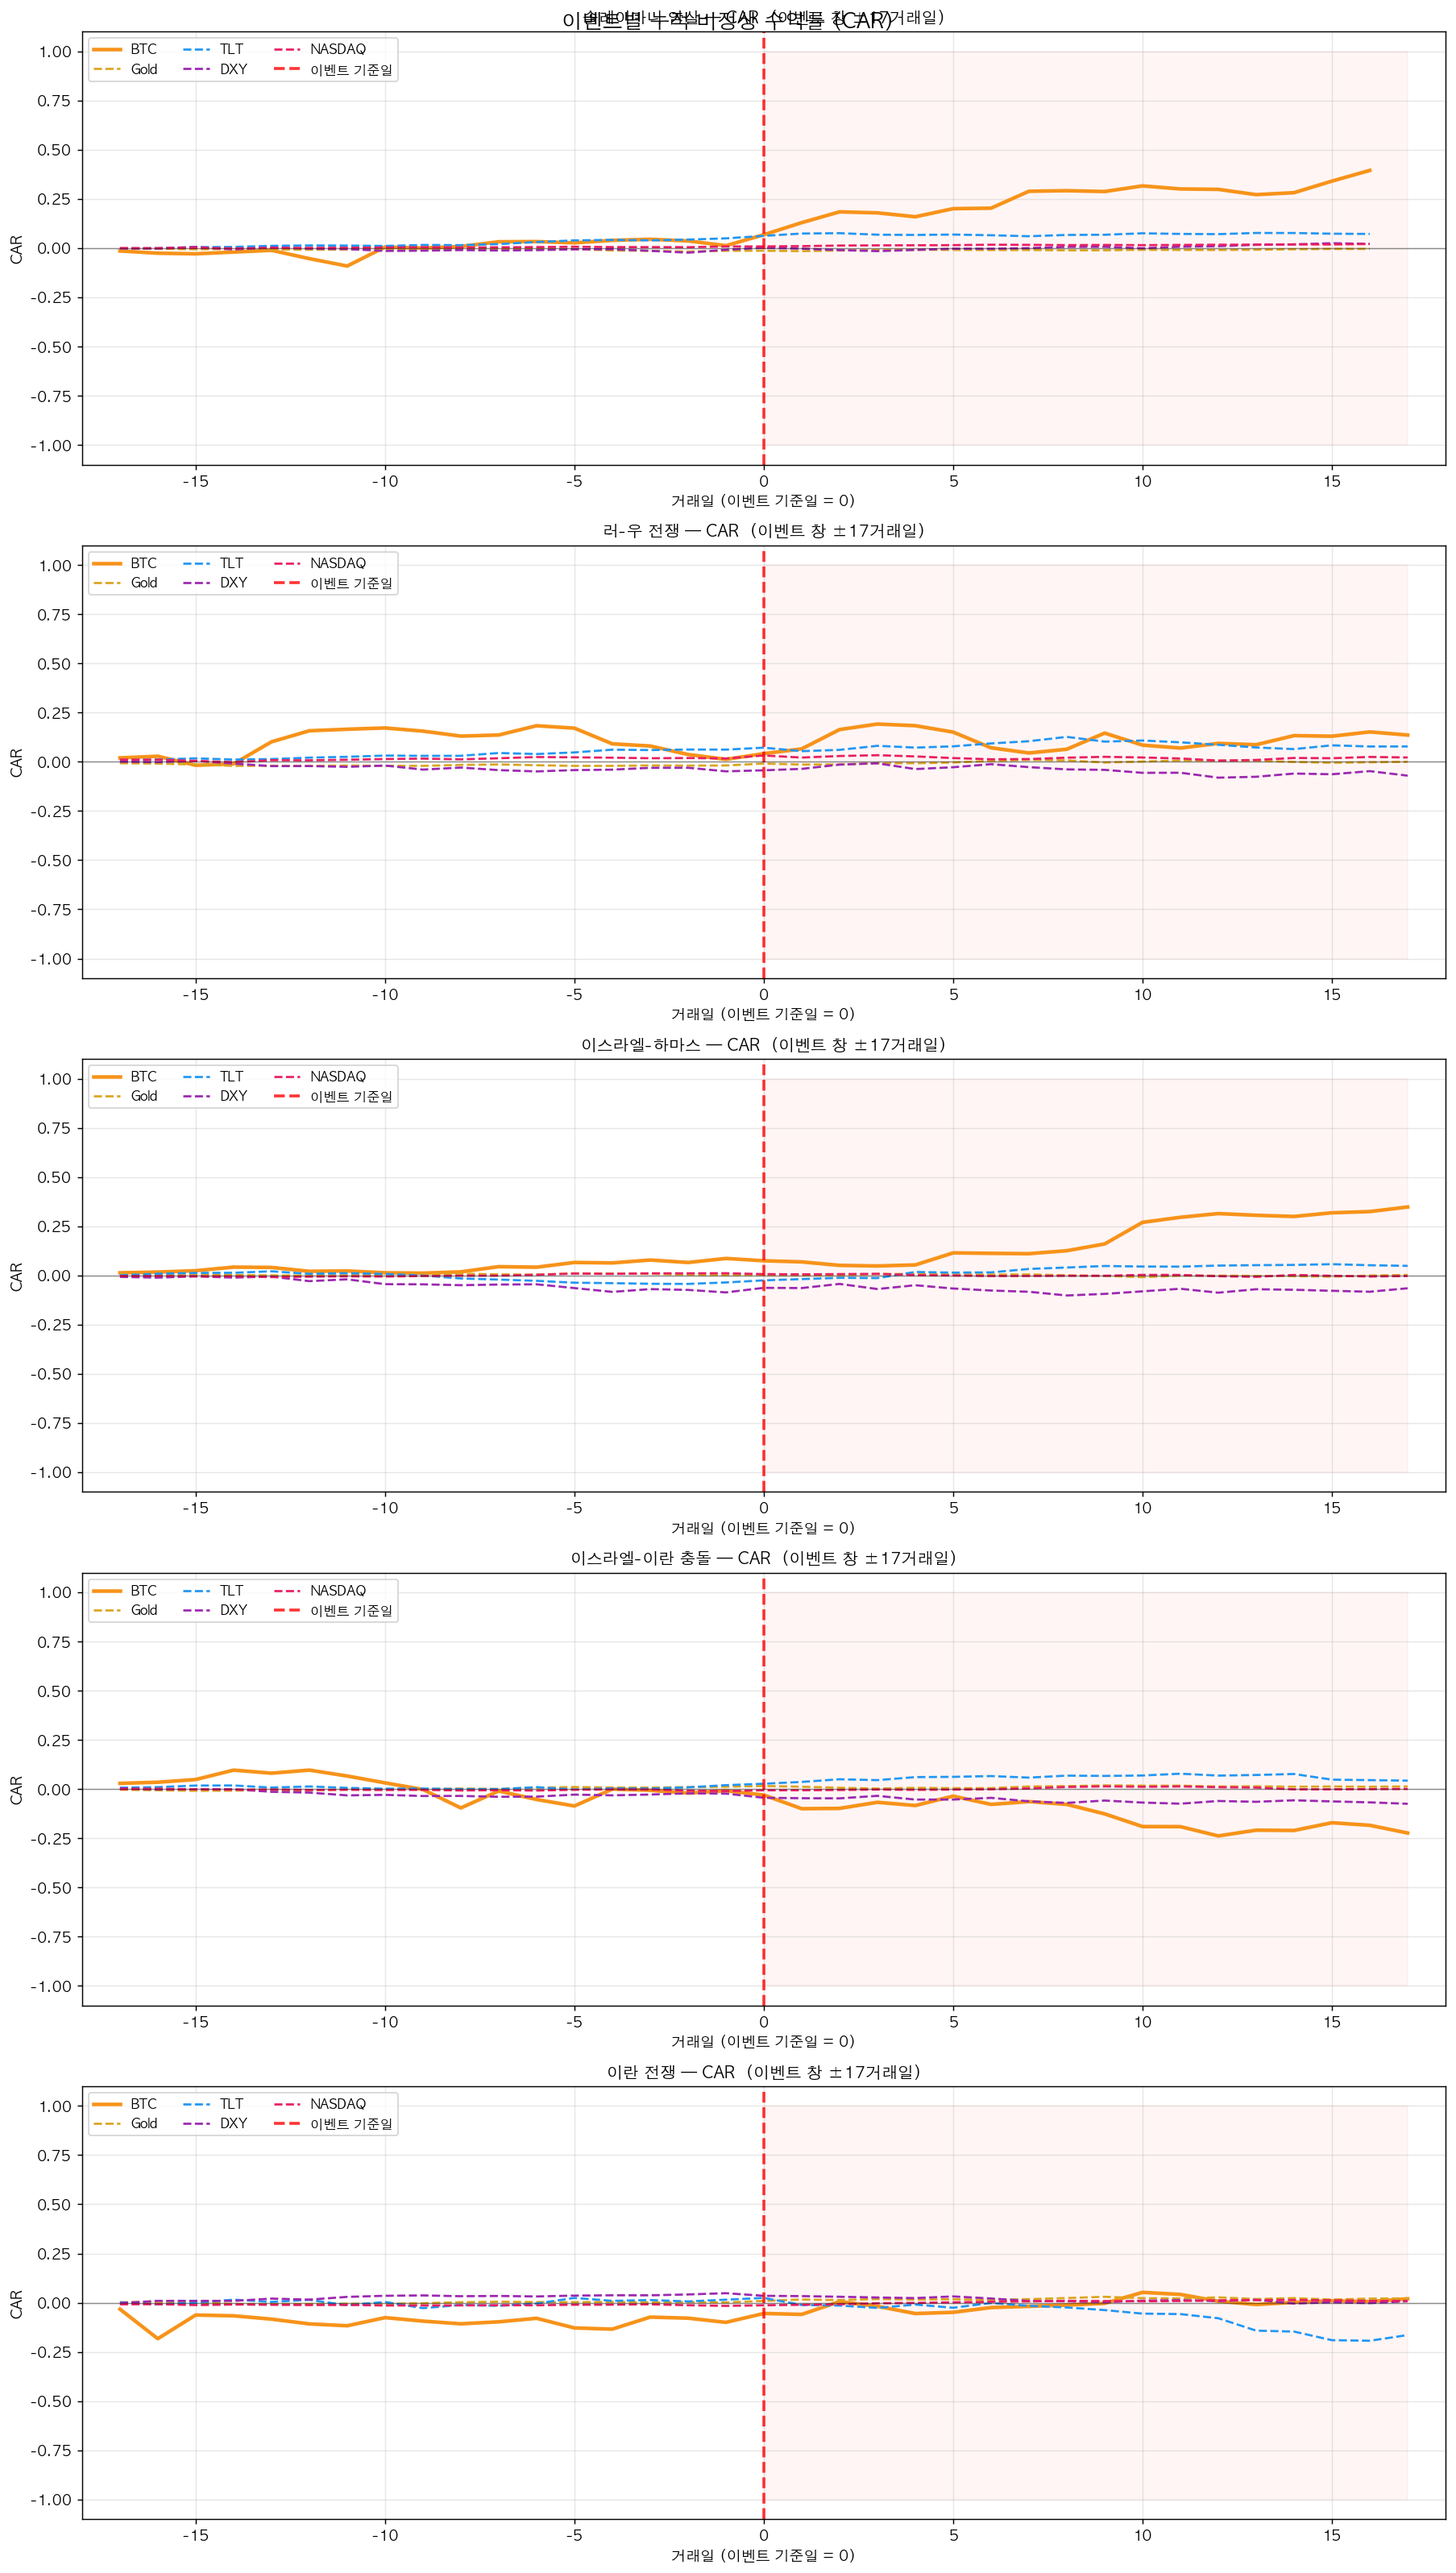

✅ event_study_CAR_timeseries.png 저장


In [9]:
# ── 6-1. 이벤트별 CAR 시계열 ────────────────────────
valid_events = [e for e in EVENT_DATES if car_results.get(e)]
n = len(valid_events)
fig, axes = plt.subplots(n, 1, figsize=(14, 5*n))
if n == 1: axes = [axes]

for ax, event in zip(axes, valid_events):
    car = car_results[event]
    for asset, df_ar in car.items():
        if len(df_ar) == 0:
            continue
        lw = 2.5 if asset == 'BTC' else 1.5
        ls = '-'  if asset == 'BTC' else '--'
        ax.plot(df_ar['day_offset'], df_ar['CAR'],
                color=ASSET_COLORS.get(asset, 'gray'),
                lw=lw, ls=ls, label=asset)

    ax.axvline(0, color='red', lw=2, ls='--', alpha=0.8, label='이벤트 기준일')
    ax.axhline(0, color='black', lw=0.8, alpha=0.4)
    ax.fill_betweenx([-1,1], 0, EVENT_WINDOW, alpha=0.04, color='red')
    ax.set_xlim(-EVENT_WINDOW-1, EVENT_WINDOW+1)
    ax.set_title(
        f'{EVENT_LABELS.get(event,event)} — CAR  (이벤트 창 ±{EVENT_WINDOW}거래일)',
        fontsize=11, fontweight='bold')
    ax.set_xlabel('거래일 (이벤트 기준일 = 0)')
    ax.set_ylabel('CAR')
    ax.legend(fontsize=9, loc='upper left', ncol=3)
    ax.grid(alpha=0.3)

plt.suptitle('이벤트별 누적 비정상 수익률 (CAR)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('event_study_CAR_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ event_study_CAR_timeseries.png 저장')

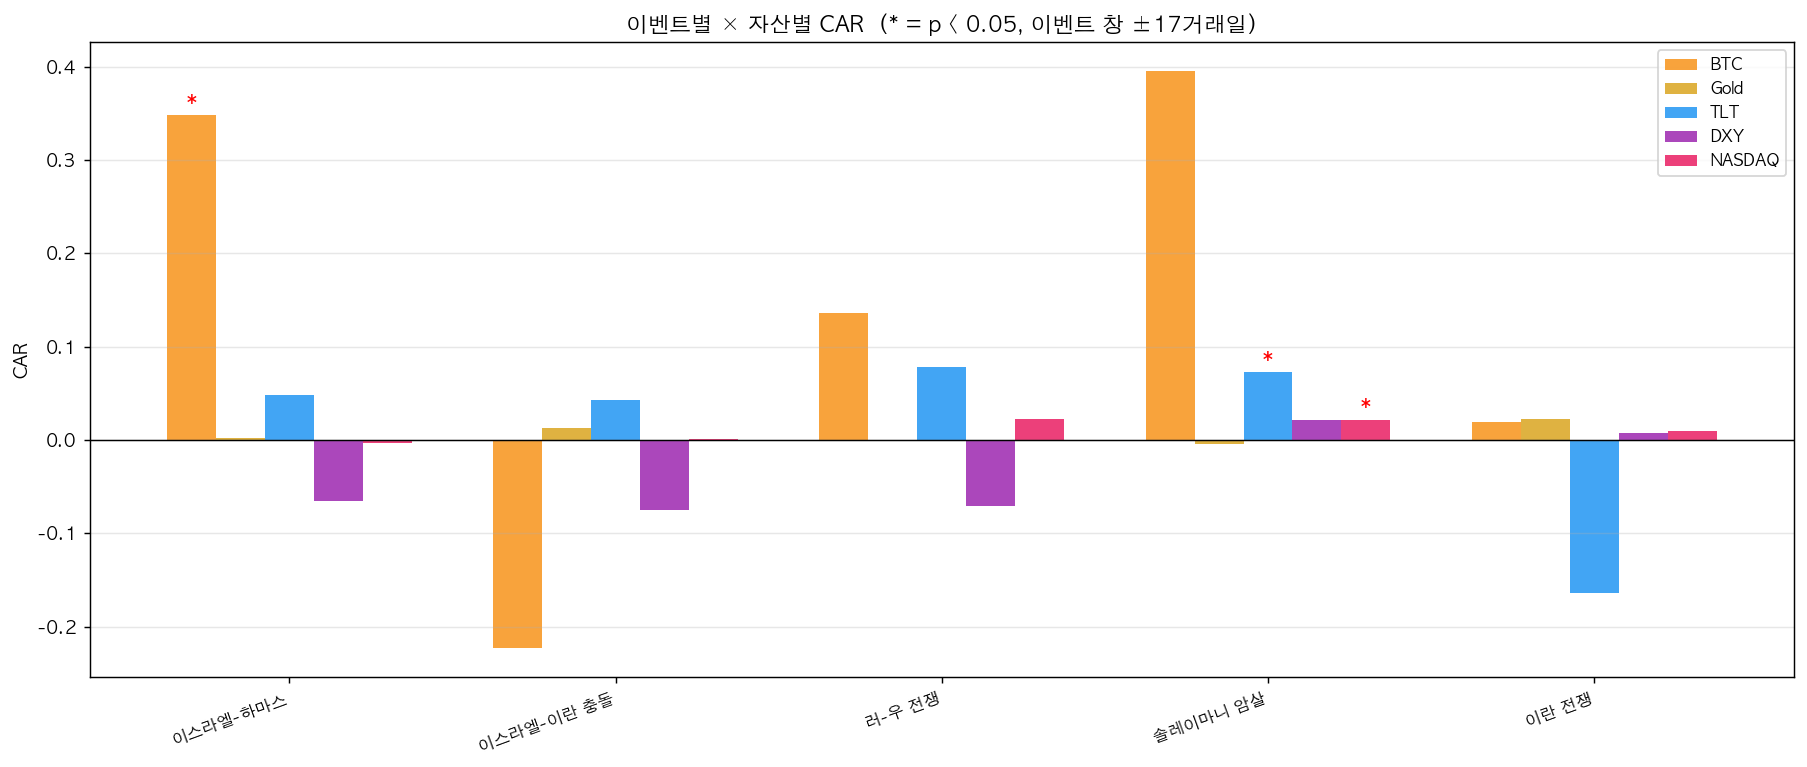

✅ event_study_CAR_bar.png 저장


In [10]:
# ── 6-2. 자산별 × 이벤트별 CAR 막대그래프 ──────────
if len(sig_df) == 0:
    print('결과 없음')
else:
    pivot = sig_df.pivot_table(
        index='event', columns='asset', values='CAR', aggfunc='first'
    ).reindex(columns=ASSETS)

    x     = np.arange(len(pivot))
    width = 0.15
    fig, ax = plt.subplots(figsize=(14, 6))
    clrs = ['#F7931A','#DAA520','#2196F3','#9C27B0','#E91E63']

    for i, asset in enumerate(ASSETS):
        if asset not in pivot.columns:
            continue
        vals = pivot[asset].fillna(0).values
        bars = ax.bar(x + i*width, vals, width,
                      label=asset, color=clrs[i], alpha=0.85)
        # 유의한 항목에 * 표시
        for j, (bar, ev) in enumerate(zip(bars, pivot.index)):
            row = sig_df[(sig_df['event']==ev)&(sig_df['asset']==asset)]
            if len(row) > 0 and pd.notna(row['p_t'].values[0]) \
                    and row['p_t'].values[0] < 0.05:
                yoff = 0.002 if bar.get_height() >= 0 else -0.008
                ax.text(bar.get_x()+bar.get_width()/2,
                        bar.get_height()+yoff,
                        '*', ha='center', fontsize=14, color='red')

    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(x + width*2)
    ax.set_xticklabels(
        [EVENT_LABELS.get(e,e) for e in pivot.index],
        rotation=20, ha='right', fontsize=9)
    ax.set_ylabel('CAR')
    ax.set_title(f'이벤트별 × 자산별 CAR  (* = p < 0.05, 이벤트 창 ±{EVENT_WINDOW}거래일)',
                  fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('event_study_CAR_bar.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ event_study_CAR_bar.png 저장')

---
## Step 7. Baur & Lucey (2010) 최종 분류

In [11]:
if len(sig_df) == 0:
    print('결과 없음')
else:
    print('=' * 80)
    print('Baur & Lucey (2010) 최종 분류')
    print('=' * 80)

    # BTC 요약
    btc_df = sig_df[sig_df['asset'] == 'BTC'].copy()
    print(f'\n▶ BTC Safe-Haven 가설 검증:\n')
    summary = []
    for _, r in btc_df.iterrows():
        lbl = r['label'].replace('🟢 ','').replace('🔴 ','').replace('🔵 ','').replace('⚪ ','')
        summary.append({
            '이벤트'    : EVENT_LABELS.get(r['event'], r['event']),
            'CAR'       : round(r['CAR'], 4),
            'p-value(t)': round(r['p_t'], 4),
            'p-boot'    : round(r['p_boot'], 4) if pd.notna(r['p_boot']) else '-',
            '유의(5%)'  : r['sig'],
            '결론'      : r['label'],
        })
    display(pd.DataFrame(summary).set_index('이벤트'))

    # 전체 자산 피벗
    print('\n▶ 전체 자산 분류표:\n')
    pivot_lbl = sig_df.pivot_table(
        index='event', columns='asset', values='label', aggfunc='first'
    )
    pivot_lbl.index = [EVENT_LABELS.get(e,e) for e in pivot_lbl.index]
    display(pivot_lbl)

Baur & Lucey (2010) 최종 분류

▶ BTC Safe-Haven 가설 검증:



,CAR,p-value(t),p-boot,유의(5%),결론
이벤트,,,,,
솔레이마니 암살,0.3951,0.0532,0.0900,—,🔵 Diversifier
러-우 전쟁,0.1359,0.6019,0.5350,—,🔵 Diversifier
이스라엘-하마스,0.3477,0.0195,0.0212,✅,🟢 Safe Haven
이스라엘-이란 충돌,-0.2234,0.3599,0.1972,—,⚪ 비유의
이란 전쟁,0.0194,0.9393,0.8928,—,🔵 Diversifier



▶ 전체 자산 분류표:



asset,BTC,DXY,Gold,NASDAQ,TLT
이스라엘-하마스,🟢 Safe Haven,⚪ 비유의,🔵 Diversifier,⚪ 비유의,🔵 Diversifier
이스라엘-이란 충돌,⚪ 비유의,⚪ 비유의,🔵 Diversifier,🔵 Diversifier,🔵 Diversifier
러-우 전쟁,🔵 Diversifier,⚪ 비유의,⚪ 비유의,🔵 Diversifier,🔵 Diversifier
솔레이마니 암살,🔵 Diversifier,🔵 Diversifier,⚪ 비유의,🟢 Safe Haven,🟢 Safe Haven
이란 전쟁,🔵 Diversifier,🔵 Diversifier,🔵 Diversifier,🔵 Diversifier,⚪ 비유의


---
## Step 8. 결과 저장

In [12]:
# 검정 결과
sig_df.to_csv('event_study_results.csv', index=False, encoding='utf-8-sig')

# AR 시계열 (이벤트별 × 자산별)
ar_rows = []
for event, car in car_results.items():
    for asset, df_ar in car.items():
        tmp = df_ar.copy()
        tmp['event_name'] = event
        tmp['asset']      = asset
        ar_rows.append(tmp)
if ar_rows:
    pd.concat(ar_rows, ignore_index=True).to_csv(
        'event_study_AR_timeseries.csv', index=False, encoding='utf-8-sig')

print('▶ 최종 산출물:')
for f in ['event_study_results.csv',
          'event_study_AR_timeseries.csv',
          'event_study_CAR_timeseries.png',
          'event_study_CAR_bar.png']:
    flag = '✅' if os.path.exists(f) else '📄 (실행 후 생성)'
    print(f'  {flag} {f}')

▶ 최종 산출물:
  ✅ event_study_results.csv
  ✅ event_study_AR_timeseries.csv
  ✅ event_study_CAR_timeseries.png
  ✅ event_study_CAR_bar.png
